In [9]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit import transpile

num_qubits = 3
target_state = '101' 

circ = QuantumCircuit(num_qubits, num_qubits)
circ.h(range(num_qubits))

#oracle
def make_oracle(num_qubits, target_state):
    oracle_circ = QuantumCircuit(num_qubits)
    for idx, val in enumerate(reversed(target_state)):
        if val == '0':
            oracle_circ.x(idx)
    oracle_circ.h(num_qubits - 1)
    oracle_circ.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    oracle_circ.h(num_qubits - 1)
    for idx, val in enumerate(reversed(target_state)):
        if val == '0':
            oracle_circ.x(idx)
    oracle_gate = oracle_circ.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

#diffusion operator
def make_diffuser(num_qubits):
    diff_circ = QuantumCircuit(num_qubits)
    diff_circ.h(range(num_qubits))
    diff_circ.x(range(num_qubits))
    diff_circ.h(num_qubits - 1)
    diff_circ.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    diff_circ.h(num_qubits - 1)
    diff_circ.x(range(num_qubits))
    diff_circ.h(range(num_qubits))
    diffuser_gate = diff_circ.to_gate()
    diffuser_gate.name = "Diffuser"
    return diffuser_gate

steps = int(np.floor((np.pi*1.0) / 4 * np.sqrt(2**num_qubits)))


In [10]:
def get_amplitudes(num_qubits, target_state, steps):
    idx = int(target_state, 2)
    oracle_gate = make_oracle(num_qubits, target_state)
    diffuser_gate = make_diffuser(num_qubits)

    state = Statevector.from_label('0'*num_qubits)
    state = state.evolve(circ)

    amplitude_vals = [abs(state.data[idx])]

    for _ in range(steps):
        state = state.evolve(oracle_gate)
        state = state.evolve(diffuser_gate)
        amplitude_vals.append(abs(state.data[idx]))

    return amplitude_vals

def get_counts(num_qubits, target_state, steps):
    oracle_gate = make_oracle(num_qubits, target_state)
    diffuser_gate = make_diffuser(num_qubits)

    for _ in range(steps):
        circ.append(oracle_gate,   range(num_qubits))
        circ.append(diffuser_gate, range(num_qubits))
    circ.measure(range(num_qubits), range(num_qubits))                 

    sim = AerSimulator()
    nshots = 2048

    compiled = transpile(circ, sim)
    outcome = sim.run(compiled, shots=nshots).result()
    result_counts = outcome.get_counts(compiled)
    return result_counts

{'101': 1942, '011': 15, '111': 19, '100': 14, '000': 20, '010': 14, '110': 18, '001': 6}


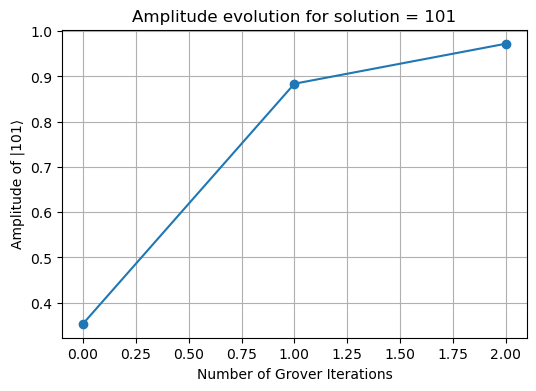

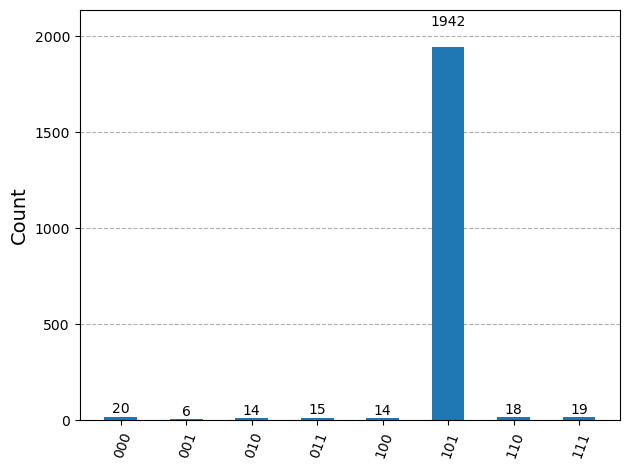

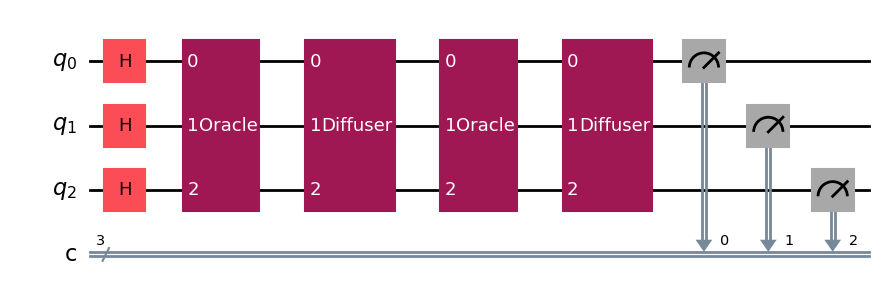

In [11]:
amplitude_vals = get_amplitudes(num_qubits, target_state, steps)
result_counts = get_counts(num_qubits, target_state, steps)
print(result_counts)
plt.figure(figsize=(6,4))
plt.plot(range(len(amplitude_vals)), amplitude_vals, 'o-')
plt.xlabel('Number of Grover Iterations')
plt.ylabel('Amplitude of |{}⟩'.format(target_state))
plt.title(f'Amplitude evolution for solution = {target_state}')
plt.grid(True)
plt.show()
fig = plot_histogram(result_counts)
display(fig)
circ.draw('mpl')

In [12]:
# 3 SAT problem
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.circuit.library import PhaseOracle
import itertools

formula = "(x1 |  ~x2 | x3) & (~x1 | x2 | x3)"

oracle3sat = PhaseOracle(formula)
oracle3sat.name = "Oracle"

circ = QuantumCircuit(num_qubits, num_qubits)
circ.h(range(num_qubits))

num_qubits = oracle3sat.num_qubits

{'011': 273, '000': 267, '110': 267, '100': 273, '101': 238, '111': 244, '001': 232, '010': 254}


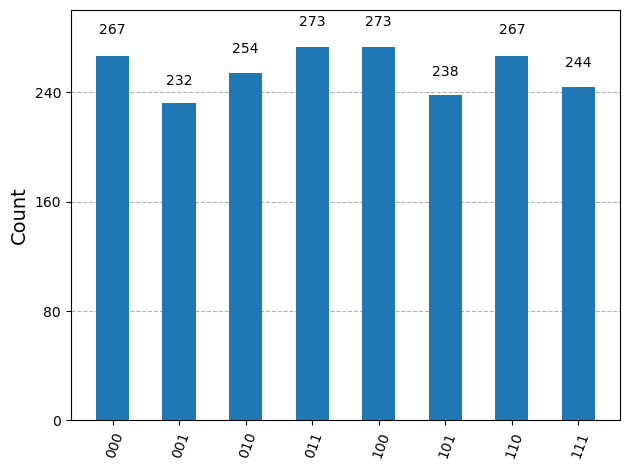

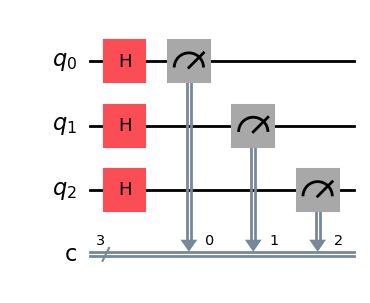

In [13]:
def make_diffuser(num_qubits):
    diff_circ = QuantumCircuit(num_qubits)
    diff_circ.h(range(num_qubits))
    diff_circ.x(range(num_qubits))
    diff_circ.h(num_qubits - 1)
    diff_circ.mcx(list(range(num_qubits - 1)), num_qubits - 1) 
    diff_circ.h(num_qubits - 1)
    diff_circ.x(range(num_qubits))
    diff_circ.h(range(num_qubits))
    diffuser_gate = diff_circ.to_gate()
    diffuser_gate.name = "Diffuser"
    return diffuser_gate

%matplotlib inline

diffuser3sat = make_diffuser(num_qubits)

valid_solutions = 0

def sat_checker(bits):
    b1, b2, b3 = bits
    cond1 = (b1 == 1) or (b2 == 0) or (b3 == 1)
    cond2 = (b1 == 0) or (b2 == 1) or (b3 == 1)
    return int(cond1 and cond2)

for bitstring in itertools.product([0,1], repeat=num_qubits):
    if sat_checker(bitstring):
        valid_solutions += 1

steps = int(np.floor((np.pi*1.0) / 4 * np.sqrt((2**num_qubits)/(valid_solutions))))

for _ in range(steps):
    circ.append(oracle3sat,   range(num_qubits))
    circ.append(diffuser3sat, range(num_qubits))

circ.measure(range(num_qubits), range(num_qubits))                 
sim = AerSimulator()
nshots = 2048

compiled = transpile(circ, sim)
outcome = sim.run(compiled, shots=nshots).result()
result_counts = outcome.get_counts(compiled)

print(result_counts)
fig1 = plot_histogram(result_counts)
display(fig1)
circ.draw('mpl')